In [1]:
import numpy as np
from itertools import combinations

lstms_stack = np.load('lstms_stack.npy')

n_repeats = 32
n_maps = 32
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) // 2
pairs = combinations(np.arange(n_players), 2)
n_pcs = 142
pc_pairs = n_pcs*(n_pcs-1)//2 + n_pcs

In [20]:
a_lstms = lstms_stack[:12,0,:]
b_lstms = lstms_stack[:12,1,:10]
a_lstms.shape

(12, 142)

In [25]:
from sklearn.cross_decomposition import CCA

n_components=5
cca = CCA(n_components=n_components)
'''cca.fit(X_train, Y_train)
X_train_r, Y_train_r = cca.transform(X_train, Y_train)
X_test_r, Y_test_r = cca.transform(X_test, Y_test)'''
a_scores, b_scores = cca.fit_transform(a_lstms, b_lstms)

In [30]:
print(cca.x_weights_.shape,
cca.y_weights_.shape,
cca.x_loadings_.shape,
cca.y_loadings_.shape,
cca.x_rotations_.shape,
cca.y_rotations_.shape,
cca.coef_.shape,
a_scores.shape, 
b_scores.shape)

#weights: left & right singular vectors of the corr. matrix of X,Y corresponding to the highest singular value
#loadings: (INCONSISTENT NOMENCLATURE) correlation between X/Y var.s and X/Y canonical variates
#rotations: transformation matrix (X->U and Y->V)
#coef: coefficients in the final correlation
#scores: dataset transformed into canonical variables (n_components)

(142, 5) (10, 5) (142, 5) (10, 5) (142, 5) (10, 5) (142, 10) (12, 5) (12, 5)


In [31]:
#summary: scores is the transformed data to use for ISC, etc.

a_scores, b_scores

(array([[-2.58006834,  1.44528168,  2.36711748,  2.10496178, -4.02397785],
        [ 7.74020503, -0.8501657 , -0.69148511, -3.45191776,  1.39505291],
        [ 7.74020503,  2.21043081,  1.7978613 ,  0.2427936 , -0.2593907 ],
        [ 7.74020503, -1.36026512, -1.10637618,  3.20912416, -1.13566221],
        [-2.58006834,  6.54627587, -3.9217789 ,  0.0124669 ,  0.03068448],
        [-2.58006834,  2.21043081,  2.98945408, -1.59398492,  5.48779888],
        [-2.58006834, -3.6557125 , -1.7817932 , -0.77381135,  1.54007436],
        [-2.58006834, -1.87036453, -0.37060704, -2.1023576 , -2.17040707],
        [-2.58006834, -1.10521541,  0.21079699, -1.71471373, -2.3949814 ],
        [-2.58006834, -1.10521541,  0.21079699, -1.71471373, -2.3949814 ],
        [-2.58006834,  0.17003314,  1.28895723,  2.13187581,  0.11486228],
        [-2.58006834, -2.63551366, -0.99294364,  3.65027684,  3.81092772]]),
 array([[-5.52770798e-01,  3.65077628e-01,  8.08129467e-01,
          8.53250045e-02, -1.33048341e

<BarContainer object of 5 artists>

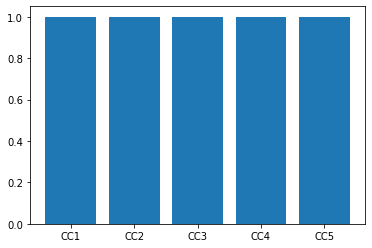

In [34]:
import matplotlib.pyplot as plt

comp_corr = [np.corrcoef(a_scores[:, i], b_scores[:, i])[1][0] for i in range(n_components)]
plt.bar(['CC1', 'CC2', 'CC3', 'CC4', 'CC5'], comp_corr)